In [6]:
import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1, 0, 0], [0, 1, 0],[0, 0, 1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample, columns = ['feature1', 'feature2', 'feature3'])
df['target'] = 1

mu_vec2 = np.array([1, 1, 1])
cov_mat2 = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample, columns=['feature1', 'feature2', 'feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index = True)

df = df.sample(40)

In [7]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


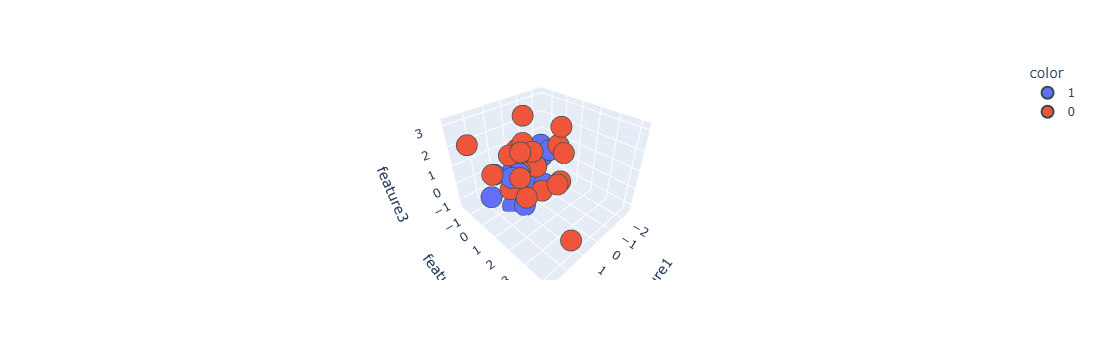

In [11]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y = df['feature2'], z=df['feature3'],
                   color = df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                               line = dict(width =2, 
                                          color = 'DarkSlateGrey')),
                 selector = dict(mode = 'markers'))

fig.show()
                    

In [12]:
# step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:, 0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [13]:
# step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:, 0], df.iloc[:, 1], df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [14]:
# step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [15]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [16]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

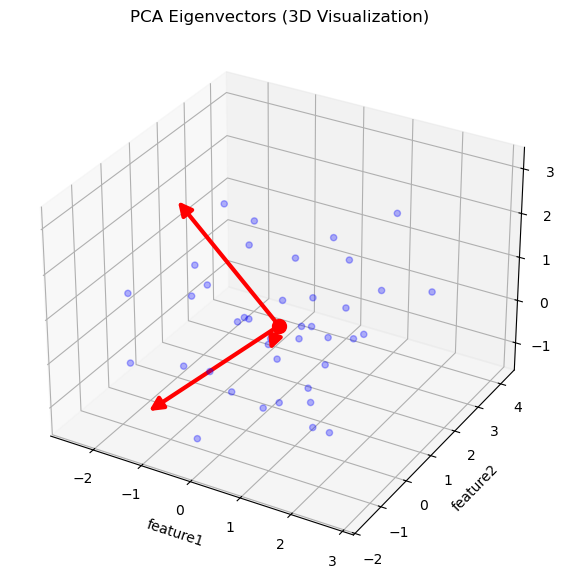

In [22]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

# -----------------------------
# Generate Data
# -----------------------------
np.random.seed(23)

mu_vec1 = np.array([0, 0, 0])
cov_mat1 = np.eye(3)
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample, columns=['feature1', 'feature2', 'feature3'])
df['target'] = 1

mu_vec2 = np.array([1, 1, 1])
cov_mat2 = np.eye(3)
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample, columns=['feature1', 'feature2', 'feature3'])
df1['target'] = 0

# ✅ FIXED CONCAT
df = pd.concat([df, df1], ignore_index=True)

# shuffle
df = df.sample(40, random_state=23)

# -----------------------------
# PCA (Eigen Decomposition)
# -----------------------------
X = df[['feature1', 'feature2', 'feature3']].values

# mean center
mean_vec = np.mean(X, axis=0)
X_centered = X - mean_vec

# covariance matrix
cov_mat = np.cov(X_centered.T)

# eigen decomposition
eigen_values, eigen_vectors = np.linalg.eig(cov_mat)

# -----------------------------
# Arrow Class (FIXED)
# -----------------------------
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.get_proj())
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
        return 0

# -----------------------------
# Plot
# -----------------------------
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# scatter points
ax.scatter(df['feature1'], df['feature2'], df['feature3'],
           color='blue', alpha=0.3)

# mean point
ax.scatter(mean_vec[0], mean_vec[1], mean_vec[2],
           color='red', s=100)

# eigenvectors (arrows)
for v in eigen_vectors.T:
    v_scaled = v * 3  # scale for visibility
    arrow = Arrow3D(
        [mean_vec[0], mean_vec[0] + v_scaled[0]],
        [mean_vec[1], mean_vec[1] + v_scaled[1]],
        [mean_vec[2], mean_vec[2] + v_scaled[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="red"
    )
    ax.add_artist(arrow)

# labels
ax.set_xlabel('feature1')
ax.set_ylabel('feature2')
ax.set_zlabel('feature3')

plt.title('PCA Eigenvectors (3D Visualization)')
plt.show()

In [23]:
pc = eigen_vectors[0:2]
pc

array([[-0.61002583, -0.69239396,  0.3853039 ],
       [-0.53982115,  0.00718615, -0.84174906]])

In [25]:
transformed_df = np.dot(df.iloc[:, 0:3], pc.T)
# 40, 3 - 3, 2
new_df = pd.DataFrame(transformed_df, columns = ['PC1', 'PC2'])
new_df['target'] = df['target'].values

new_df.head()

,PC1,PC2,target
0,1.571096,-0.353855,1
1,-0.714905,-2.494424,0
2,0.459927,-0.022297,1
3,-3.953371,-0.807297,0
4,-0.475664,-3.746533,0


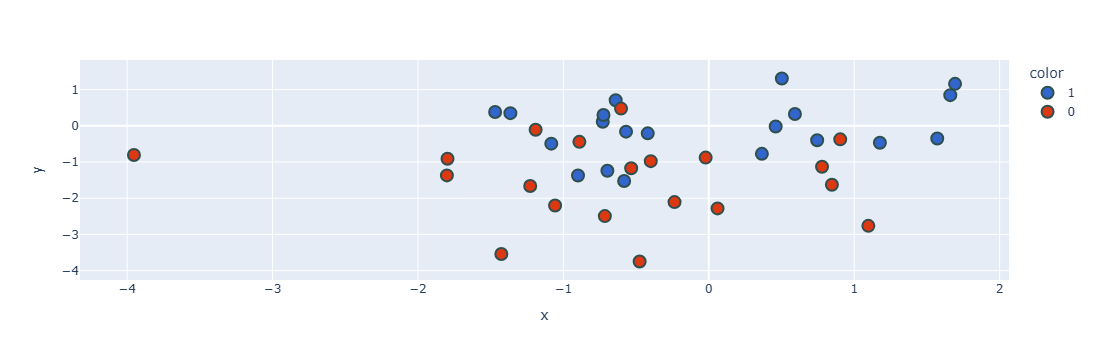

In [29]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()